# Laboratory 3 - Hypothesis Testing in Network Analysis

## LastFM Asia Social Network

### Laboratory Task

The purpose of this laboratory is to apply inferential network analysis to a
real network dataset and determine whether an observed network pattern is
unusual relative to an explicitly defined reference model.

The analysis follows the workflow:

**Research question → Network representation → Network mechanism →
Hypotheses → Null model → Statistical test → Interpretation**

For this laboratory, the **LastFM Asia Social Network** used in Laboratory 2
is analysed again.

The network mechanism investigated is **homophily**.

### Research Question

**Are connected LastFM users more likely to belong to the same country-derived
target class than would be expected under random assignment of the target
labels?**

## 1.1 Dataset Description

The **LastFM Asia Social Network** is a publicly available social-network
dataset from the Stanford Network Analysis Project (SNAP).

Dataset source:

https://snap.stanford.edu/data/feather-lastfm-social.html

The network contains:

- **7,624 nodes**
- **27,806 edges**

A node represents a LastFM user from an Asian country.

An edge represents a mutual follower relationship between two users.

The graph is therefore treated as:

- **undirected**
- **unweighted**

The dataset also provides a target variable derived from users' country
information. The provided files encode these countries as numeric target
classes.

These target classes will be used to investigate homophily.

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import json

edges = pd.read_csv("lastfm_asia_edges.csv")
target = pd.read_csv("lastfm_asia_target.csv")

with open("lastfm_asia_features.json", "r") as file:
    features = json.load(file)

edges.head()

,node_1,node_2
0,0,747
1,1,4257
2,1,2194
3,1,580
4,1,6478


In [3]:
G = nx.from_pandas_edgelist(
    edges,
    source="node_1",
    target="node_2",
    create_using=nx.Graph()
)

G.add_nodes_from(target["id"])

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 7624
Number of edges: 27806


In [4]:
density = nx.density(G)

print("Density:", round(density, 6))

Density: 0.000957


In [5]:
transitivity = nx.transitivity(G)

print("Transitivity:", round(transitivity, 4))

Transitivity: 0.1786


In [6]:
from networkx.algorithms.community import louvain_communities, modularity

communities = louvain_communities(
    G,
    weight=None,
    seed=42
)

modularity_score = modularity(
    G,
    communities,
    weight=None
)

print("Detected communities:", len(communities))
print("Modularity:", round(modularity_score, 4))

Detected communities: 27
Modularity: 0.8127


Mechanism: Homophily

H0:
The observed level of same-target connections is compatible with
random placement of target labels on the observed network.

H1:
The network contains more same-target connections than expected
under random placement of target labels.

# 3. Research Question and Hypotheses

## 3.1 Network Mechanism: Homophily

The network mechanism investigated in this laboratory is **homophily**.

Homophily refers to the tendency of actors with similar characteristics to
form relationships with one another.

In the LastFM Asia dataset, every user has a numeric target class derived from
country information. Therefore, the analysis investigates whether users
connected through mutual follower relationships are more likely to belong to
the same country-derived target class than would be expected by chance.

## 3.2 Research Question

**Are connected LastFM users more likely to belong to the same country-derived
target class than would be expected under random assignment of the target
labels?**

## 3.3 Hypotheses

### Null Hypothesis (H₀)

The country-derived target labels are unrelated to the observed follower
relationships.

The proportion of edges connecting users from the same target class should
therefore be similar to what would be expected if the target labels were
randomly assigned to users.

### Alternative Hypothesis (H₁)

Connected LastFM users belong to the same country-derived target class more
frequently than expected under random assignment of the target labels.

This would be consistent with a homophily pattern in the network.

## 3.4 Network Statistic

The statistic used to evaluate homophily is the **proportion of network edges
connecting users with the same target class**.

For every edge between users i and j:

- the edge is counted as a same-target edge if target(i) = target(j);
- otherwise, it is counted as a different-target edge.

The observed statistic is therefore:

Same-target proportion = Same-target edges / Total edges

A high observed proportion alone is not sufficient evidence of homophily.
It must be compared with an appropriate null/reference distribution.

In [7]:
# Create node -> target mapping

target_map = target.set_index("id")["target"]

# Add target class for both endpoints of every edge

edges_with_target = edges.copy()

edges_with_target["target_1"] = (
    edges_with_target["node_1"].map(target_map)
)

edges_with_target["target_2"] = (
    edges_with_target["node_2"].map(target_map)
)

# Check for missing target values

print(
    "Missing target values:",
    edges_with_target[
        ["target_1", "target_2"]
    ].isna().sum().sum()
)

edges_with_target.head()

Missing target values: 0


,node_1,node_2,target_1,target_2
0,0,747,8,8
1,1,4257,17,17
2,1,2194,17,6
3,1,580,17,16
4,1,6478,17,17


In [9]:
# Determine whether each edge connects users
# belonging to the same target class

edges_with_target["same_target"] = (
    edges_with_target["target_1"]
    == edges_with_target["target_2"]
)


# Number of same-target edges

observed_same_edges = (
    edges_with_target["same_target"].sum()
)


# Total number of edges

total_edges = len(edges_with_target)


# Observed same-target proportion

observed_same_proportion = (
    observed_same_edges
    / total_edges
)


print(
    "Same-target edges:",
    observed_same_edges
)

print(
    "Total edges:",
    total_edges
)

print(
    "Observed same-target proportion:",
    round(observed_same_proportion, 4)
)

print(
    "Observed same-target percentage:",
    round(observed_same_proportion * 100, 2),
    "%"
)

Same-target edges: 24299
Total edges: 27806
Observed same-target proportion: 0.8739
Observed same-target percentage: 87.39 %


## 3.5 Observed Homophily Statistic

In the original LastFM network, **24,299 of the 27,806 edges** connect users
belonging to the same country-derived target class.

This corresponds to an observed same-target proportion of approximately
**0.8739**, or **87.39%**.

Therefore, most mutual follower relationships connect users belonging to the
same target category.

However, this observation alone does not establish that the pattern is unusual.
Some target classes may contain many more users than others, meaning that a
relatively high same-target proportion could occur partly because of the class
distribution.

For this reason, the observed statistic must be compared with a null model
that preserves the target-class frequencies while removing the association
between users' target labels and their positions in the network.

# 4. Null / Reference Model

## 4.1 Label-Permutation Null Model

A **label-permutation null model** is used.

The observed LastFM network itself is kept unchanged. The same 7,624 users and
27,806 mutual follower relationships are preserved.

The country-derived target labels are then randomly shuffled among the users.

### What is preserved?

The null model preserves:

- all 7,624 nodes;
- all 27,806 edges;
- the complete follower network structure;
- each user's degree;
- the total number of users in each target class.

### What is randomized?

Only the assignment of target labels to individual users is randomized.

### Why is this appropriate?

If target class is unrelated to network relationships, then randomly assigning
the existing labels to users should produce same-target edge proportions that
are compatible with the null hypothesis.

Comparing the observed statistic with this randomized distribution therefore
tests whether the association between target similarity and follower
relationships is stronger than would be expected under random label placement.

In [10]:
# Create an index position for each user ID

id_to_position = pd.Series(
    np.arange(len(target)),
    index=target["id"]
)


# Convert edge endpoints to positions

edge_u = (
    edges["node_1"]
    .map(id_to_position)
    .to_numpy()
)

edge_v = (
    edges["node_2"]
    .map(id_to_position)
    .to_numpy()
)


# Original target labels

target_labels = target["target"].to_numpy()

## 4.2 Permutation Procedure

The target labels are randomly permuted **1,000 times**.

For each permutation:

1. the network structure remains unchanged;
2. target labels are randomly reassigned to users;
3. the proportion of edges connecting equal target labels is calculated;
4. the resulting statistic is stored.

The 1,000 simulated values form the null/reference distribution.

In [11]:
# Number of permutations

n_permutations = 1000


# Reproducible random generator

rng = np.random.default_rng(42)


# Store null statistics

null_proportions = np.empty(
    n_permutations
)


# Run permutations

for i in range(n_permutations):

    # Randomly shuffle target labels
    permuted_labels = rng.permutation(
        target_labels
    )

    # Compare target labels at edge endpoints
    same_target_permuted = (
        permuted_labels[edge_u]
        == permuted_labels[edge_v]
    )

    # Store proportion
    null_proportions[i] = (
        same_target_permuted.mean()
    )

In [12]:
print(
    "Null mean:",
    round(null_proportions.mean(), 4)
)

print(
    "Null standard deviation:",
    round(null_proportions.std(ddof=1), 4)
)

print(
    "Minimum null value:",
    round(null_proportions.min(), 4)
)

print(
    "Maximum null value:",
    round(null_proportions.max(), 4)
)

print(
    "Observed value:",
    round(observed_same_proportion, 4)
)

Null mean: 0.1193
Null standard deviation: 0.0029
Minimum null value: 0.1107
Maximum null value: 0.1311
Observed value: 0.8739


In [13]:
# Number of randomized statistics at least
# as large as the observed statistic

extreme_count = np.sum(
    null_proportions
    >= observed_same_proportion
)


# Permutation p-value
# +1 correction avoids reporting p = 0

p_value = (
    extreme_count + 1
) / (
    n_permutations + 1
)


print(
    "Extreme permutations:",
    extreme_count
)

print(
    "Permutation p-value:",
    round(p_value, 6)
)

Extreme permutations: 0
Permutation p-value: 0.000999


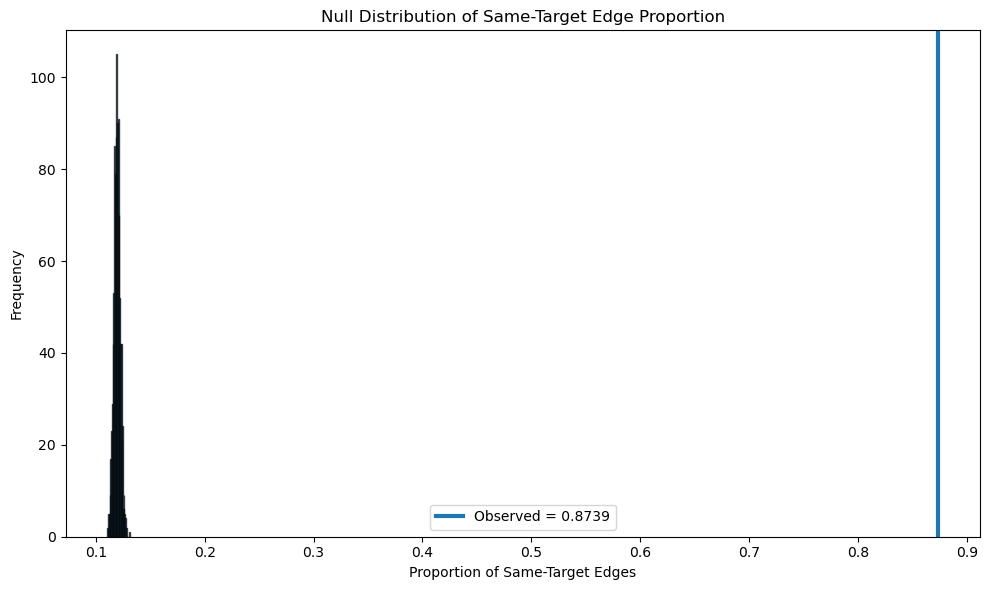

In [16]:
plt.figure(figsize=(10, 6))

plt.hist(
    null_proportions,
    bins=30,
    edgecolor="black",
    alpha=0.7
)

plt.axvline(
    observed_same_proportion,
    linewidth=3,
    label=(
        f"Observed = "
        f"{observed_same_proportion:.4f}"
    )
)

plt.xlabel(
    "Proportion of Same-Target Edges"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Null Distribution of Same-Target Edge Proportion"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "lab3_homophily_null_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5.3 Statistical Inference

The observed same-target edge proportion is **0.8739 (87.39%)**.

Under the label-permutation null model, the average same-target proportion is
approximately **0.1193 (11.93%)**.

Across 1,000 permutations, none of the randomized networks produced a
same-target proportion as large as the observed value.

Using the standard permutation-test correction, the one-sided p-value is
approximately:

**p = 0.001**

Therefore, the observed same-target connectivity is highly unusual under the
chosen null model.

The null hypothesis is rejected.

The result is consistent with a strong association between target-class
similarity and mutual follower relationships in the LastFM Asia network.

# 6. Interpretation

The permutation analysis shows that users belonging to the same country-derived
target class are connected much more frequently than would be expected if those
target labels were randomly distributed across the existing network.

In the observed network, approximately **87.39%** of mutual follower
relationships connect users from the same target class. Under random target
assignment, the expected proportion is only about **11.93%**.

This large difference is consistent with a strong **homophily pattern**:
users with the same country-derived attribute tend to be located together in
the follower network.

However, this result should be interpreted as an **association**, not as proof
that country similarity directly caused users to follow one another.

A plausible alternative explanation is **geographic or linguistic opportunity**.
Users from the same country may share language, local social circles, events,
or regional online environments that increase the opportunity for them to
connect.

Other unobserved factors, such as shared music preferences or platform
recommendation mechanisms, may also contribute to the observed pattern.

Therefore, the result shows that the observed network is not compatible with
a model in which country-derived labels are randomly positioned, but it does
not by itself establish the causal process that produced the network.

# 7. AI Use Statement

Generative AI was used as a supporting tool during this laboratory.

The AI tool used was **Claude AI**.

It was used to help with:

- structuring the Jupyter Notebook;
- writing and checking Python code;
- implementing the permutation test;
- creating the null-distribution visualization;
- explaining the statistical results in clear language;
- organizing the final interpretation.

All code was executed and checked in Jupyter Notebook using the actual **LastFM
Asia** dataset.

I reviewed the outputs and compared them with the requirements from the
laboratory instructions and lecture materials.

One methodological point that was specifically checked was the choice of the
null model.

Instead of randomizing the network edges, the analysis keeps the observed
network structure fixed and randomly permutes the country-derived target
labels among users.

This approach was retained because the research question concerns whether
target-class similarity is associated with the existing follower
relationships. Permuting the labels removes this association while preserving
the network topology and the frequency of each target class.

The interpretation of the result was also checked carefully to avoid making
causal claims. The permutation test shows an association between target
similarity and network ties, but it does not prove that geographic similarity
caused users to connect.

# 8. Conclusion

This laboratory tested whether the observed LastFM Asia follower network is
compatible with a null model in which users' country-derived target labels are
randomly distributed across the network.

The network contains **7,624 users** and **27,806 mutual follower
relationships**.

The mechanism investigated was **homophily**.

In the observed network, approximately **87.39%** of edges connect users with
the same country-derived target class.

To evaluate whether this pattern could occur by chance, the target labels were
randomly permuted **1,000 times** while the network structure was kept fixed.

Under the null model, the mean same-target edge proportion was approximately
**11.93%**, which is much lower than the observed value.

None of the 1,000 permutations produced a statistic as large as the observed
one. The corrected one-sided permutation p-value was approximately
**0.001**.

Therefore, the null hypothesis was rejected.

The observed network is not compatible with random placement of the target
labels and is instead consistent with a strong association between target-class
similarity and mutual follower relationships.

This result is consistent with a homophily pattern, but it does not prove that
country similarity caused the relationships to form.

Other factors, including language, geographic opportunity, shared music
preferences, social circles, or recommendation mechanisms, could also
contribute to the observed structure.

Overall, the analysis demonstrates how permutation testing can be used to move
from a descriptive network pattern to an inferential conclusion by comparing
the observed statistic with an explicitly defined reference model.